# ③ CNN + Transformer 单点时序预测：完整实现 · 精度检验 · 调参 · 改进

> **数据-物理融合驱动的岩土工程风险评估 —— 算法系列 ③**
> 场景：与 ① 相同的**单点位移预测**（边坡/库岸单个 GNSS 测点，日尺度，多环境驱动），但换一套更强的时序架构。
> ① 的 LSTM 是**递归网络**：信息沿时间逐步传递，窗口加长时梯度路径变长、且无法并行；
> 本篇用 **CNN 前置 + Transformer** 的混合架构，把"局部规律"和"全局依赖"分给最擅长它们的组件。

**分工**：
- **CNN（因果一维卷积）= 局部模式扫描仪**：卷积核只看相邻几天，专门捕捉**周期性波动、短期趋势、事件响应的局部形态**；权值共享 + 局部感受野带来强归纳偏置——小样本下比注意力更稳、参数更省；
- **Transformer（自注意力）= 全局观察者**：注意力让**任意两个时间步直接相连**（信息路径长度 O(1)，RNN 是 O(T)），建模"一个事件在几十个时间步后产生延迟影响"的**长距离依赖**，整窗并行计算。

**流水线**：原始多变量序列 →（CNN 前置）含局部模式的"特征图" →（+ 位置编码）→ Transformer 编码器建模长依赖 → 取最后时刻表示 → 回归头输出未来速率。

**目录**
1. 环境配置
2. 演示数据（含【替换为真实数据】接口）
3. 防泄漏预处理与样本构造（与 ① 同一套流水线）
4. 原理与 NumPy 从零实现：因果 Conv1D 与自注意力（梯度检查 + PyTorch 官方对齐）+ 位置编码
5. PyTorch 混合模型（CNN / Transformer 可开关，支撑消融）
6. 训练（同 ① 标准：早停 / LR 调度 / 梯度裁剪）
7. 精度检验（速率 + 累积重构两级口径 + 递归多步）
8. 调参（随机搜索）+ SEQ_LEN 窗口敏感性
9. 改进（消融实验、注意力可视化、卷积响应核物理先验、MC Dropout）
10. 汇总与接入真实数据清单

In [1]:
import math, random, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__} | device = {DEVICE} | MPS available: {torch.backends.mps.is_available()}")

plt.rcParams["font.sans-serif"] = ["PingFang SC", "Hiragino Sans GB", "Microsoft YaHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

import matplotlib.dates as mdates
def fix_date_axis(ax, max_ticks=7):
    loc = mdates.AutoDateLocator(minticks=3, maxticks=max_ticks)
    ax.xaxis.set_major_locator(loc)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))
    return ax

PyTorch 2.9.1 | device = cpu | MPS available: True


## 2. 演示数据（可整体替换为真实数据）

合成一个库岸边坡测点的 6 年日尺度多变量序列（机制与 ① 完全同款，便于两套架构公平对比）：

$$v_t = \underbrace{v_0 e^{-t/T}}_{\text{蠕变衰减}} + \underbrace{a\,R^{eff}_t}_{\text{降雨响应}} + \underbrace{b\,\max(0,-\Delta L_t)}_{\text{库水位骤降}} + \varepsilon_t$$

- **$R^{eff}_t$ = 有效降雨**：日降雨与一阶指数滞后核（$\tau=12$ 天）卷积——降雨入渗经非饱和带补给坡体存在**渗流滞后**，这正是"局部模式 + 延迟响应"的物理来源，也是本架构（CNN 响应核 + 注意力长依赖）最该发挥的地方；
- $\varepsilon_t$ = 观测噪声底（任何模型都不可预报的部分）。
- 数据以监测系统常见的长表格式存储：`date, 驱动列..., disp_mm`。

In [2]:
def make_synthetic_data(n_days=2190, start="2016-01-01", seed=0):
    """合成库岸边坡日尺度多变量序列（仅用于跑通流程；机制与算法①一致）。"""
    rng = np.random.default_rng(seed)
    t = np.arange(n_days)
    doy = pd.date_range(start, periods=n_days).dayofyear.to_numpy()

    # 1) 降雨：雨季(7-8月)强 + 随机暴雨
    seasonal = 0.5 + 0.5 * np.cos(2 * np.pi * (doy - 200) / 365)
    rain = rng.gamma(shape=0.9, scale=12.0, size=n_days) * seasonal
    storm = (rng.random(n_days) < 0.03) * rng.gamma(2.0, 60.0, size=n_days)
    rain = np.clip(rain + storm, 0, None)

    # 2) 库水位：年周期 + 小噪声；差分为骤降项
    level = 160 - 15 * np.cos(2 * np.pi * (doy - 105) / 365) + rng.normal(0, 0.4, n_days)
    dlevel = np.gradient(level)                                        # m/day（负值 = 骤降）

    # 3) 温度
    temp = 17 + 10 * np.sin(2 * np.pi * (doy - 100) / 365) + rng.normal(0, 1.5, n_days)

    # 4) 有效降雨：一阶指数滞后核（渗透滞后 τ=12 天，窗口 60 天）
    tau, K = 12.0, 60
    w = np.exp(-np.arange(K) / tau); w /= w.sum()
    eff_rain = np.convolve(rain, w, mode="full")[:n_days]

    # 5) 位移速率 → 累积位移
    creep = 0.9 * np.exp(-t / 650.0)                # mm/day，随时间衰减的蠕变
    resp = 0.10 * eff_rain + 0.9 * np.clip(-dlevel, 0, None)
    vel = creep + resp + rng.normal(0, 0.15, n_days)
    disp = np.cumsum(np.clip(vel, 0, None))         # mm

    return pd.DataFrame({"date": pd.date_range(start, periods=n_days),
                         "rainfall_mm": rain, "reservoir_m": level,
                         "temp_c": temp, "disp_mm": disp})

df_raw = make_synthetic_data()
df_raw.to_csv("demo_ct_geodata.csv", index=False)   # 存为 CSV，之后当作"真实数据"来读
print(df_raw.shape)
df_raw.head()

(2190, 5)


,date,rainfall_mm,reservoir_m,temp_c,disp_mm
0,2016-01-01,0.218364,163.551307,8.494965,2.162372
1,2016-01-02,0.336965,162.291151,8.501532,3.514549
2,2016-01-03,0.154186,162.138355,8.021471,4.401052
3,2016-01-04,0.110442,162.464550,7.617819,5.255903
4,2016-01-05,0.259013,162.133255,7.351304,6.229391


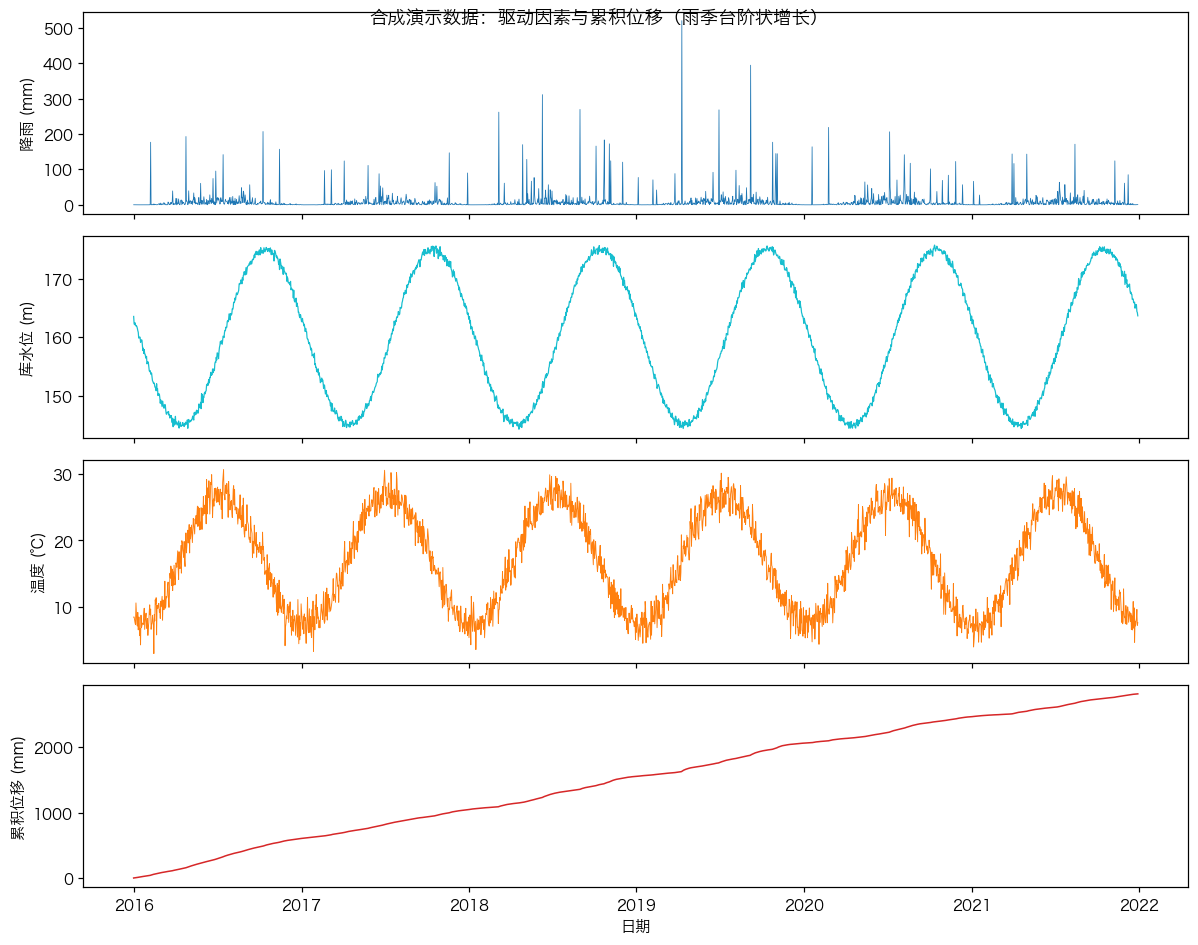

In [3]:
fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
axes[0].plot(df_raw.date, df_raw.rainfall_mm, lw=.5, color="tab:blue");   axes[0].set_ylabel("降雨 (mm)")
axes[1].plot(df_raw.date, df_raw.reservoir_m, lw=.8, color="tab:cyan");   axes[1].set_ylabel("库水位 (m)")
axes[2].plot(df_raw.date, df_raw.temp_c, lw=.6, color="tab:orange");      axes[2].set_ylabel("温度 (℃)")
axes[3].plot(df_raw.date, df_raw.disp_mm, lw=1.0, color="tab:red");       axes[3].set_ylabel("累积位移 (mm)")
axes[3].set_xlabel("日期")
fig.suptitle("合成演示数据：驱动因素与累积位移（雨季台阶状增长）", y=0.95)
plt.tight_layout(); plt.show()

### 2.2 【替换为真实数据】只需改这一格

真实数据是单点长表 CSV（`date, 驱动列..., disp_mm`）：

```python
DATA_PATH = "your_monitoring.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["date"]).sort_values("date")
df["disp_rate_mm"] = df["disp_mm"].diff()          # 位移速率 = 累积位移一阶差分（mm/day）
df = df.dropna(subset=["disp_rate_mm"])
FEATURE_COLS = ["rainfall_mm", "reservoir_m", "temp_c", "disp_rate_mm"]   # 驱动特征（含目标自身 = 自回归）
TARGET_COL   = "disp_rate_mm"
```

**适用场景**：单点位移/沉降长序列、裂缝计、测斜孔口位移等。多测点监测网请用算法②（GCN）；
本架构也可作为 ② 中 GRU 的时间模块替换（Transformer 时间 + GCN 空间），见 §10.3 进阶路线。

In [4]:
# ================== 配置区：换数据只改这里 ==================
DATA_PATH = "demo_ct_geodata.csv"                                     # ← 换成你的 CSV

df = pd.read_csv(DATA_PATH, parse_dates=["date"]).sort_values("date").reset_index(drop=True)
df["disp_rate_mm"] = df["disp_mm"].diff()          # 位移速率 = 累积位移一阶差分（mm/day）
df = df.dropna(subset=["disp_rate_mm"]).reset_index(drop=True)

FEATURE_COLS = ["rainfall_mm", "reservoir_m", "temp_c", "disp_rate_mm"]   # ← 驱动特征（含目标自身 = 自回归）
TARGET_COL   = "disp_rate_mm"                                             # ← 预测目标：位移速率

SEQ_LEN, HORIZON    = 60, 1        # 回看窗口(天) / 预测步长（多步用 §7 递归；60 天窗口正是为"长依赖"留空间）
VAL_FRAC, TEST_FRAC = 0.15, 0.15   # 时序划分比例
BATCH_SIZE          = 64
RAIN_IDX = FEATURE_COLS.index("rainfall_mm")                              # 降雨通道索引（§9.3 物理正则用）

print(f"样本数 = {len(df)}, 时间范围 = {df.date.iloc[0].date()} ~ {df.date.iloc[-1].date()}")
df[FEATURE_COLS].describe().T[["mean", "std", "min", "max"]]

样本数 = 2189, 时间范围 = 2016-01-02 ~ 2021-12-29


,mean,std,min,max
rainfall_mm,9.110420,27.325874,0.000003,520.744455
reservoir_m,159.998092,10.625752,144.263423,175.754357
temp_c,17.039061,7.189182,3.005575,30.668609
disp_rate_mm,1.285465,0.649219,0.000000,4.743759


## 3. 数据预处理（防泄漏，与 ① 同一套流水线）

- 标准化器只在**训练时段**拟合；目标列若同时作为输入（自回归），输入与输出**共用同一标准化** → 递归预测可直接回填；
- **目标 = 位移速率**（mm/day）：非平稳的累积位移不可外推（① §3 / §9.2 有完整论证），预测速率后再重构累积值；
- 样本：`(SEQ_LEN, F) 窗口 → 目标日速率`，按**目标时刻**划分 train/val/test，绝不随机打乱。

In [5]:
def clean_series(df_in, cols):
    """缺失值线性插值 + 4σ 截尾。
    注：严格的防泄漏做法是截尾阈值只用训练段统计量；此处为演示从简。"""
    d = df_in.copy()
    d[cols] = d[cols].interpolate(limit_direction="both")
    for c in cols:
        mu, sd = d[c].mean(), d[c].std()
        d[c] = d[c].clip(mu - 4 * sd, mu + 4 * sd)
    return d

df = clean_series(df, list(dict.fromkeys(FEATURE_COLS + [TARGET_COL])))
assert df[FEATURE_COLS].isna().sum().sum() == 0, "仍有缺失，请检查数据"

In [6]:
def make_windows(X, y, seq_len, horizon):
    """滑窗：X[t-seq_len : t] → y[t+horizon-1]（单步）。
    注意 y 保持二维 (M, horizon)：否则 (B,1) 的预测与 (B,) 的标签做 MSE 会错误广播。"""
    xs, ys = [], []
    for t in range(seq_len, len(y) - horizon + 1):
        xs.append(X[t - seq_len:t])
        ys.append(y[t + horizon - 1:t + horizon] if horizon == 1 else y[t:t + horizon])
    return np.asarray(xs, "float32"), np.asarray(ys, "float32")


def build_arrays(df_in, feature_cols, target_col, seq_len=SEQ_LEN, horizon=HORIZON,
                 val_frac=VAL_FRAC, test_frac=TEST_FRAC):
    """防泄漏数据流水线：原始 DataFrame → train/val/test 数组。
    1) 标准化器只在训练段拟合；
    2) 目标列若同时作为输入（自回归），输入与输出共用同一标准化 → 递归预测可直接回填；
    3) 样本按"目标时刻"所属区间划分。"""
    cols = list(dict.fromkeys(feature_cols))          # 去重、保序
    n = len(df_in)
    i_test = n - int(n * test_frac)
    i_val = i_test - int(n * val_frac)

    exog_cols = [c for c in cols if c != target_col]
    x_scaler = StandardScaler().fit(df_in[exog_cols].iloc[:i_val]) if exog_cols else None
    y_scaler = StandardScaler().fit(df_in[[target_col]].iloc[:i_val])

    X = np.empty((n, len(cols)), dtype="float32")
    if exog_cols:
        X[:, [cols.index(c) for c in exog_cols]] = x_scaler.transform(df_in[exog_cols])
    if target_col in cols:
        X[:, cols.index(target_col)] = y_scaler.transform(df_in[[target_col]]).ravel()

    y = y_scaler.transform(df_in[[target_col]]).astype("float32").ravel()
    Xw, yw = make_windows(X, y, seq_len, horizon)

    ends = np.arange(seq_len, n - horizon + 1) + horizon - 1   # 每个样本"目标"的时间索引
    m_tr = ends < i_val
    m_va = (ends >= i_val) & (ends < i_test)
    m_te = ends >= i_test
    return dict(X=Xw, y=yw, Xfull=X,          # X: (M, seq_len, F) 滑窗样本；Xfull: (n, F) 完整标准化序列(递归预测取窗用)
                ends=ends, m_tr=m_tr, m_va=m_va, m_te=m_te,
                i_val=i_val, i_test=i_test, cols=cols,
                x_scaler=x_scaler, y_scaler=y_scaler, n=n,
                disp=df_in["disp_mm"].to_numpy(), dates=df_in["date"].to_numpy())

prep = build_arrays(df, FEATURE_COLS, TARGET_COL)
for s in ("tr", "va", "te"):
    print(f"{s}: X {prep['X'][prep['m_' + s]].shape}, y {prep['y'][prep['m_' + s]].shape}")

tr: X (1473, 60, 4), y (1473, 1)
va: X (328, 60, 4), y (328, 1)
te: X (328, 60, 4), y (328, 1)


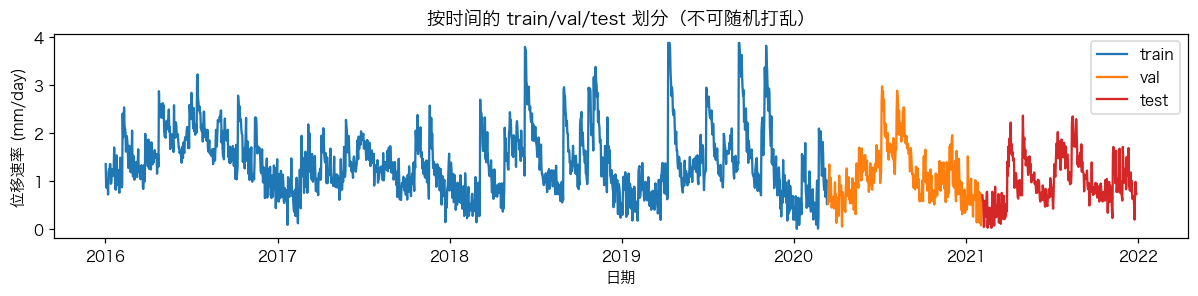

In [7]:
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X, self.y = torch.from_numpy(X), torch.from_numpy(y)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        return self.X[i], self.y[i]

def make_loader(X, y, batch_size=64, shuffle=False):
    return DataLoader(SeqDataset(X, y), batch_size=batch_size, shuffle=shuffle)

# 时序划分可视化
plt.figure(figsize=(11, 2.8))
plt.plot(df["date"][:prep["i_val"]], df[TARGET_COL][:prep["i_val"]], label="train", color="tab:blue")
plt.plot(df["date"][prep["i_val"]:prep["i_test"]], df[TARGET_COL][prep["i_val"]:prep["i_test"]], label="val", color="tab:orange")
plt.plot(df["date"][prep["i_test"]:], df[TARGET_COL][prep["i_test"]:], label="test", color="tab:red")
plt.legend(); plt.ylabel("位移速率 (mm/day)"); plt.xlabel("日期")
plt.title("按时间的 train/val/test 划分（不可随机打乱）")
plt.tight_layout(); plt.show()

## 4. 原理与 NumPy 从零实现

### 4.1 因果一维卷积：局部模式扫描仪

对输入序列 $x$，卷积核 $w \in \mathbb{R}^K$ 在时刻 $t$ 的输出：

$$\text{out}_t = \sum_{j=0}^{K-1} w_j\, x_{t-K+1+j} + b$$

- **因果（causal）**：只在序列**左侧**补 $K-1$ 个零 → 输出长度不变，且 $\text{out}_t$ 只依赖 $\le t$ 的输入（时间不倒流，部署/递归时不会"偷看未来"）；
- **权值共享**：同一个核扫过整条序列 → 参数量与序列长度无关，对"局部形态"（周期波峰、暴雨台阶）有强归纳偏置；
- **膨胀（dilation）$d$**：核隔 $d$ 天采样，触到 $x_{t-(K-1)d+j\cdot d}$。堆 $L$ 层的总感受野
  $\text{RF} = 1 + \sum_l (K_l - 1)\, d_l$（如 $K=5,\ d=(1,2)$ 两层 → $\text{RF}=13$ 天），用很少的层数把局部模式窗口拉宽。

**岩土含义**：卷积核本质上是一个**可学习的响应核**——第一层作用在降雨通道上的核，就是"过去 $K$ 天降雨对当前速率的线性响应系数"。若它学成**非负、滞后衰减**的形态，正好对应降雨入渗的渗流滞后（§9.3 把这个物理先验写成软约束）。

> 与 ①② 同理：先从零实现吃透维度与反向传播，再用 PyTorch 实战；§4.2 数值梯度检查 + 与官方 `conv1d` 对齐。

In [8]:
class NumPyCausalConv1d:
    """单通道因果一维卷积：out[t] = Σ_j w[j]·x[t−K+1+j] + b（w[0] 乘最旧样本）。
    与 torch 等价：F.conv1d(F.pad(x, (K−1, 0)), w)[0, 0]（见 §4.2 对齐）。"""

    def __init__(self, K, seed=0):
        rng = np.random.default_rng(seed)
        self.K = K
        self.w = rng.normal(0, np.sqrt(2 / K), K)              # Kaiming 初始化
        self.b = 0.0

    def forward(self, x):
        T = len(x)
        xp = np.concatenate([np.zeros(self.K - 1), x])         # 左侧补零 = 因果
        self.cache = np.stack([xp[i:i + T] for i in range(self.K)])   # (K, T) 滑窗矩阵
        self.x = x
        return self.w @ self.cache + self.b

    def backward(self, dout):
        """上游梯度 dout=(T,)（MSE）。返回 dL/dw, dL/db, dL/dx。"""
        dw = self.cache @ dout                                 # (K,T)@(T,) = dL/dw
        db = dout.sum()
        dxp = np.convolve(dout, self.w)                        # dL/dxp[s] = Σ_j dout[s−j]·w[j]
        return dict(w=dw, b=db, x=dxp[self.K - 1:])            # 去掉补零位置 → dL/dx


def numerical_grad_array(f, p, eps=1e-6):
    """f: 以数组 p 为自变量的标量函数 → 中心差分数值梯度。"""
    g = np.zeros_like(p)
    it = np.nditer(p, flags=["multi_index"])
    while not it.finished:
        ix = it.multi_index
        orig = p[ix]
        p[ix] = orig + eps; l1 = f(p)
        p[ix] = orig - eps; l2 = f(p)
        p[ix] = orig
        g[ix] = (l1 - l2) / (2 * eps)
        it.iternext()
    return g

### 4.2 卷积的数值梯度检查 + 与官方 `conv1d` 对齐

In [9]:
rng_np = np.random.default_rng(0)
K_n, T_n = 5, 12
x_n = rng_np.normal(size=T_n)
y_n = rng_np.normal(size=T_n)

conv_np = NumPyCausalConv1d(K_n, seed=0)
out_n = conv_np.forward(x_n)
dout_n = 2 * (out_n - y_n) / T_n                    # MSE 的上游梯度
g_ana = conv_np.backward(dout_n)

def loss_conv(x_, w_):
    saved = conv_np.w
    conv_np.w = w_
    o = conv_np.forward(x_)
    conv_np.w = saved
    return float(np.mean((o - y_n) ** 2))

g_num_w = numerical_grad_array(lambda w_: loss_conv(x_n, w_), conv_np.w)
g_num_x = numerical_grad_array(lambda x_: loss_conv(x_, conv_np.w), x_n)
ok = True
for k, ga, gn in [("w", g_ana["w"], g_num_w), ("x", g_ana["x"], g_num_x)]:
    rel = np.max(np.abs(ga - gn) / (np.abs(ga) + np.abs(gn) + 1e-12))
    ok &= rel < 1e-5
    print(f"dL/d{k} 最大相对误差 = {rel:.2e}")
print("梯度检查：", "✅ 通过，因果卷积反向实现正确" if ok else "❌ 未通过")

# 与 torch 官方 conv1d 对齐（同权重同输入）
xt = torch.from_numpy(x_n)[None, None].double()
wt = torch.from_numpy(conv_np.w)[None, None, :].double()
ref = nn.functional.conv1d(nn.functional.pad(xt, (K_n - 1, 0)), wt)[0, 0].numpy()
diff = np.abs(ref - out_n).max()
print(f"手写卷积与 F.conv1d 最大输出差 = {diff:.2e} →",
      "✅ 对齐" if diff < 1e-12 else "❌ 不一致")

dL/dw 最大相对误差 = 2.25e-10
dL/dx 最大相对误差 = 7.49e-08
梯度检查： ✅ 通过，因果卷积反向实现正确
手写卷积与 F.conv1d 最大输出差 = 0.00e+00 → ✅ 对齐


### 4.3 自注意力：全局观察者

**缩放点积注意力**（Vaswani et al., NeurIPS 2017）：

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V,\qquad Q = XW_q,\ K = XW_k,\ V = XW_v$$

- Q/K/V 由**同一条序列**线性投影而来（**自**注意力）：softmax 行 = "预测当前时刻时，各历史时刻的重要度"——注意力矩阵就是一张**可读的长依赖地图**（§9.2 可视化）；
- $1/\sqrt{d_k}$ 防止点积随维度增大而饱和；
- **多头**：并行多组低秩投影，各头关注不同模式（一头看周期、一头看突变），拼接后投影回 $d_{model}$；
- 任意两时刻信息路径 $O(1)$（RNN 为 $O(T)$）→ 长依赖可直连；代价是 $O(T^2)$ 注意力矩阵 + **顺序信息丢失** → 必须加**位置编码**（§4.5）。

In [10]:
class NumPySelfAttention:
    """单头缩放点积自注意力（无掩码）：Q/K/V = X·W{q,k,v}，O = softmax(QKᵀ/√d_k)·V。"""

    def __init__(self, d_model, d_k, seed=0):
        rng = np.random.default_rng(seed)
        self.Wq = rng.normal(0, 1 / np.sqrt(d_model), (d_model, d_k))
        self.Wk = rng.normal(0, 1 / np.sqrt(d_model), (d_model, d_k))
        self.Wv = rng.normal(0, 1 / np.sqrt(d_model), (d_model, d_k))
        self.d_k = d_k

    def forward(self, X):
        Q, K, V = X @ self.Wq, X @ self.Wk, X @ self.Wv
        S = Q @ K.T / np.sqrt(self.d_k)
        S = S - S.max(-1, keepdims=True)                       # 数值稳定（softmax 平移不变）
        A = np.exp(S)
        A /= A.sum(-1, keepdims=True)                          # 行归一化：对"查询行"的注意力分布
        self.cache = dict(X=X, Q=Q, K=K, V=V, A=A)
        return A @ V

    def backward(self, dO):
        """上游梯度 dO=(T, d_k)。softmax 的雅可比：dS = A ∘ (dA − 行和(A∘dA))。"""
        X, Q, K, V, A = (self.cache[k] for k in ("X", "Q", "K", "V", "A"))
        dA = dO @ V.T                                          # (T, T)
        dV = A.T @ dO
        dS = A * (dA - (dA * A).sum(-1, keepdims=True))        # (T, T)
        dQ = dS @ K / np.sqrt(self.d_k)
        dK = dS.T @ Q / np.sqrt(self.d_k)
        return dict(Wq=X.T @ dQ, Wk=X.T @ dK, Wv=X.T @ dV,
                    X=dQ @ self.Wq.T + dK @ self.Wk.T + dV @ self.Wv.T)

### 4.4 注意力的数值梯度检查 + 与官方 `scaled_dot_product_attention` 对齐

反向传播最难的一段是 softmax 的雅可比：$\dfrac{\partial A_{ij}}{\partial S_{ik}} = A_{ij}(\delta_{jk} - A_{ik})$，
与上游 $dA$ 收缩后得 $dS_{ij} = A_{ij}\big(dA_{ij} - \sum_k A_{ik} dA_{ik}\big)$。用"线性探针" $\mathcal{L} = \langle dO, O\rangle$ 做梯度检查：

In [11]:
d_at, dk_at, T_at = 8, 4, 6
X_at = rng_np.normal(size=(T_at, d_at))
dO_at = rng_np.normal(size=(T_at, dk_at))

att_np = NumPySelfAttention(d_at, dk_at, seed=1)
O_at = att_np.forward(X_at)
g_ana_at = att_np.backward(dO_at)

def attn_loss(name, p):
    setattr(att_np, name, p)
    return float((att_np.forward(X_at) * dO_at).sum())

ok = True
for name in ["Wq", "Wk", "Wv"]:
    gn = numerical_grad_array(lambda p, name=name: attn_loss(name, p), getattr(att_np, name))
    ga = g_ana_at[name]
    rel = np.max(np.abs(ga - gn) / (np.abs(ga) + np.abs(gn) + 1e-12))
    ok &= rel < 1e-5
    print(f"{name} 最大相对误差 = {rel:.2e}")
print("梯度检查：", "✅ 通过，注意力反向实现正确" if ok else "❌ 未通过")

# 与 PyTorch 官方 fused 实现对齐（float64）
att2 = NumPySelfAttention(d_at, dk_at, seed=3)
O_np = att2.forward(X_at)
with torch.no_grad():
    Xt = torch.from_numpy(X_at)
    O_t = nn.functional.scaled_dot_product_attention(
        Xt @ torch.from_numpy(att2.Wq), Xt @ torch.from_numpy(att2.Wk), Xt @ torch.from_numpy(att2.Wv)).numpy()
diff = np.abs(O_t - O_np).max()
print(f"手写注意力与 scaled_dot_product_attention 最大输出差 = {diff:.2e} →",
      "✅ 对齐" if diff < 1e-12 else "❌ 不一致")

Wq 最大相对误差 = 4.27e-08
Wk 最大相对误差 = 4.21e-08
Wv 最大相对误差 = 7.61e-10
梯度检查： ✅ 通过，注意力反向实现正确
手写注意力与 scaled_dot_product_attention 最大输出差 = 2.22e-16 → ✅ 对齐


### 4.5 位置编码：把"顺序"还给注意力

注意力对输入顺序完全无感（打乱时间步输出不变）。用固定**正弦位置编码**把位置注入：

$$PE_{(pos,\,2i)} = \sin\!\big(pos / 10000^{2i/d}\big), \qquad PE_{(pos,\,2i+1)} = \cos\!\big(pos / 10000^{2i/d}\big)$$

无需训练、每行是唯一的"位置指纹"、相邻位置的编码相近（注意力可据此感知"隔多远"）、且可外推到训练时没见过的更长序列。加在 **CNN 输出之后、注意力之前**：卷积自身已编码相对顺序，注意力只缺绝对位置信息。

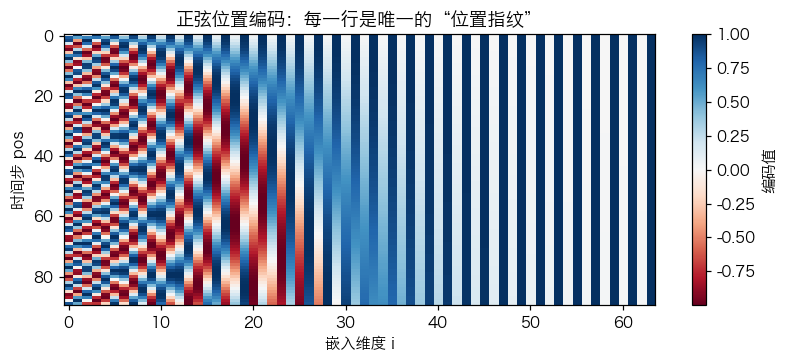

In [12]:
def sinusoidal_pe(max_len, d_model):
    pos = np.arange(max_len)[:, None]
    i = np.arange(d_model // 2)[None, :]
    ang = pos / np.power(10000.0, 2 * i / d_model)
    pe = np.zeros((max_len, d_model))
    pe[:, 0::2] = np.sin(ang)
    pe[:, 1::2] = np.cos(ang)
    return pe

pe = sinusoidal_pe(90, 64)
plt.figure(figsize=(7.5, 3.4))
plt.imshow(pe, aspect="auto", cmap="RdBu")
plt.xlabel("嵌入维度 i"); plt.ylabel("时间步 pos")
plt.title("正弦位置编码：每一行是唯一的“位置指纹”")
plt.colorbar(label="编码值")
plt.tight_layout(); plt.show()

## 5. PyTorch 混合模型 CNN-Transformer

**流水线**（CNN 前置提局部模式 → Transformer 抓长依赖）：

$$X \xrightarrow{\ \text{因果CNN塔}\ } H^{(0)} \xrightarrow{\ +PE\ } \underbrace{\text{TransformerBlock} \times L}_{\text{自注意力+FFN}} \xrightarrow{\ h_T\ } \text{Head} \to \hat y_t$$

1. **因果 CNN 塔**（2 层，$K=5$，dilation=(1,2)，RF=13 天）作用在**原始特征通道**上，先把相邻几天的局部模式压进特征；
2. 线性投影到 $d_{model}$ + 正弦位置编码；
3. **pre-LN** Transformer 编码器 $\times L$（先归一化再子层——小数据、无 warmup 下比 post-LN 稳定得多）；
4. 取**最后时刻表示** $h_T$（因果卷积保证它只汇总 $\le t$ 的信息，与递归部署一致）→ MLP 回归头。

开关：`use_cnn=False` → Transformer-only；`use_attn=False` → CNN-only（§9.1 消融用）。自定义 `TransformerBlock`（基于 `nn.MultiheadAttention`）以便 §9.2 取出注意力权重。

In [13]:
class CausalConv1d(nn.Module):
    """因果一维卷积：左侧补 (K−1)·dilation 个零，输出长度 = 输入长度，t 时刻只看得到 ≤t 的输入。"""
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1):
        super().__init__()
        self.pad = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_ch, out_ch, kernel_size, dilation=dilation)

    def forward(self, x):                                   # (B, C, T)
        return self.conv(nn.functional.pad(x, (self.pad, 0)))


class CausalConvTower(nn.Module):
    """CNN 前置特征提取塔：(B, F, T) → (B, C_out, T)。感受野 RF = 1 + Σ(K−1)·2^i。"""
    def __init__(self, f_in, hidden=48, n_layers=2, kernel=5, dropout=0.1):
        super().__init__()
        dims = [f_in] + [hidden] * n_layers
        blocks = []
        for i in range(n_layers):
            blocks += [CausalConv1d(dims[i], dims[i + 1], kernel, dilation=2 ** i),
                       nn.GELU(), nn.Dropout(dropout)]
        self.net = nn.Sequential(*blocks)
        self.receptive_field = 1 + sum((kernel - 1) * 2 ** i for i in range(n_layers))

    def forward(self, x):
        return self.net(x)


class TransformerBlock(nn.Module):
    """pre-LN 编码器块：x = x + Attn(LN(x)); x = x + FFN(LN(x))。保留注意力权重供 §9.2 可视化。"""
    def __init__(self, d_model, nhead, ff=256, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.ln2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(nn.Linear(d_model, ff), nn.GELU(),
                                 nn.Dropout(dropout), nn.Linear(ff, d_model))
        self.drop = nn.Dropout(dropout)
        self.last_attn = None

    def forward(self, x, need_weights=False):
        h = self.ln1(x)
        a, w = self.attn(h, h, h, need_weights=need_weights, average_attn_weights=True)
        if need_weights:
            self.last_attn = w.detach()                     # (B, T, T) 头平均
        x = x + self.drop(a)
        return x + self.drop(self.ffn(self.ln2(x)))


class CNNTransformerRegressor(nn.Module):
    """CNN 前置提局部模式 → (+PE) → Transformer 抓长依赖 → 最后时刻表示回归。"""
    def __init__(self, n_features, d_model=64, nhead=4, n_layers=2, ff=256,
                 kernel=5, conv_hidden=48, use_cnn=True, use_attn=True,
                 dropout=0.1, horizon=1, max_len=512):
        super().__init__()
        assert d_model % nhead == 0, "nhead 必须整除 d_model"
        self.use_cnn, self.use_attn = use_cnn, use_attn
        if use_cnn:
            self.cnn = CausalConvTower(n_features, conv_hidden, kernel=kernel, dropout=dropout)
            self.proj = nn.Linear(conv_hidden, d_model)
        else:
            self.cnn = None
            self.proj = nn.Linear(n_features, d_model)
        self.register_buffer("pe", torch.from_numpy(sinusoidal_pe(max_len, d_model)).float())
        self.blocks = nn.ModuleList([TransformerBlock(d_model, nhead, ff, dropout)
                                     for _ in range(n_layers)]) if use_attn else None
        self.ln = nn.LayerNorm(d_model)
        self.head = nn.Sequential(nn.Linear(d_model, 32), nn.GELU(),
                                  nn.Dropout(dropout), nn.Linear(32, horizon))
        parts = (["CNN"] if use_cnn else []) + (["Transformer"] if use_attn else [])
        self.model_name = "+".join(parts)

    def forward(self, x, return_attn=False):                # x: (B, T, F)
        B, T, _ = x.shape
        h = self.cnn(x.transpose(1, 2)).transpose(1, 2) if self.use_cnn else x
        h = self.proj(h) + self.pe[:T][None]                # 局部特征 + 位置编码
        for blk in (self.blocks or []):
            h = blk(h, need_weights=return_attn)
        out = self.head(self.ln(h[:, -1]))                  # 最后时刻表示 → 回归头
        if return_attn:
            return out, [b.last_attn for b in self.blocks]
        return out


model = CNNTransformerRegressor(len(FEATURE_COLS), d_model=64, nhead=4, n_layers=2,
                                kernel=5, dropout=0.1, horizon=HORIZON).to(DEVICE)
print(model.model_name, f"参数量 = {sum(p.numel() for p in model.parameters()):,}")
print(f"CNN 感受野 = {model.cnn.receptive_field} 天（回看窗口 {SEQ_LEN} 天）")
with torch.no_grad():
    print("前向输出形状:", model(torch.from_numpy(prep["X"][:4]).to(DEVICE)).shape)

CNN+Transformer 参数量 = 117,921
CNN 感受野 = 13 天（回看窗口 60 天）
前向输出形状: torch.Size([4, 1])


## 6. 训练（组件与 ①② 一致）

AdamW + 早停回滚 + `ReduceLROnPlateau` + 梯度裁剪；损失为标准化空间的 MSE。
（Transformer 惯例是 warmup + 余弦退火；本模型带 pre-LN 且规模很小，plateau 调度已足够稳定，warmup 放进 §10.3 进阶路线。）

In [14]:
class EarlyStopping:
    def __init__(self, patience=15, min_delta=1e-5):
        self.patience, self.min_delta = patience, min_delta
        self.best, self.counter, self.best_state = np.inf, 0, None

    def step(self, val_loss, model):
        if val_loss < self.best - self.min_delta:
            self.best, self.counter = val_loss, 0
            self.best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            return False
        self.counter += 1
        return self.counter >= self.patience


def run_epoch(model, loader, optimizer=None):
    train = optimizer is not None
    model.train() if train else model.eval()
    total = 0.0
    with torch.set_grad_enabled(train):
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            loss = nn.functional.mse_loss(model(xb), yb)
            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()
            total += loss.item() * len(xb)
    return total / len(loader.dataset)


def train_model(model, train_loader, val_loader, lr=1e-3, epochs=200,
                patience=20, weight_decay=1e-4, verbose=True):
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=max(patience // 3, 2))
    stop = EarlyStopping(patience=patience)
    hist = {"train": [], "val": []}
    t0 = time.time()
    for ep in range(1, epochs + 1):
        tr = run_epoch(model, train_loader, opt)
        va = run_epoch(model, val_loader)
        sched.step(va)
        hist["train"].append(tr); hist["val"].append(va)
        if verbose and (ep == 1 or ep % 20 == 0):
            print(f"epoch {ep:3d} | train {tr:.4f} | val {va:.4f} | lr {opt.param_groups[0]['lr']:.1e}")
        if stop.step(va, model):
            if verbose:
                print(f"早停于 epoch {ep}，最佳 val loss = {stop.best:.4f}（用时 {time.time()-t0:.1f}s）")
            break
    model.load_state_dict(stop.best_state)
    return hist

epoch   1 | train 0.7063 | val 0.2501 | lr 1.0e-03


epoch  20 | train 0.2410 | val 0.2969 | lr 1.0e-03


早停于 epoch 34，最佳 val loss = 0.1947（用时 57.0s）


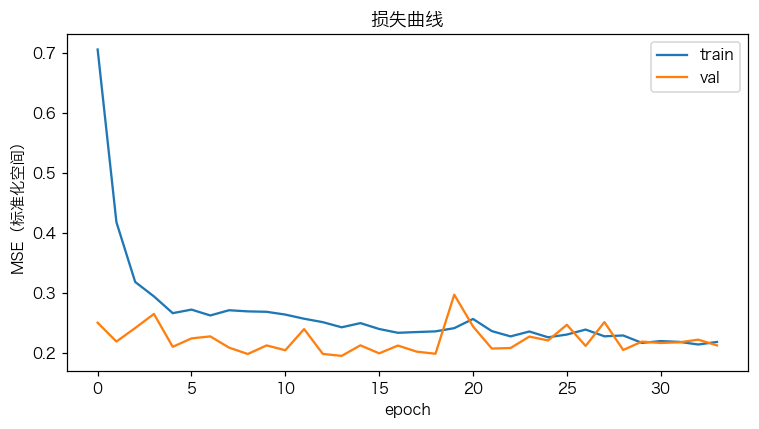

In [15]:
set_seed(SEED)
baseline_model = CNNTransformerRegressor(len(FEATURE_COLS), d_model=64, nhead=4, n_layers=2,
                                         kernel=5, dropout=0.1, horizon=HORIZON).to(DEVICE)
hist = train_model(baseline_model,
                   make_loader(prep["X"][prep["m_tr"]], prep["y"][prep["m_tr"]], BATCH_SIZE, shuffle=True),
                   make_loader(prep["X"][prep["m_va"]], prep["y"][prep["m_va"]], 256),
                   lr=1e-3, epochs=150, patience=20)

plt.figure(figsize=(7, 4))
plt.plot(hist["train"], label="train")
plt.plot(hist["val"], label="val")
plt.xlabel("epoch"); plt.ylabel("MSE（标准化空间）"); plt.title("损失曲线")
plt.legend(); plt.tight_layout(); plt.show()

## 7. 精度检验

**两级口径**（与 ①② 一致）：速率空间（mm/day，建模目标）与累积重构空间（mm，应用口径）。
另外做**递归多步预测**：把预测速率回填进输入通道滚动外推——检验长依赖建模在"误差自累积"下的稳定性，这正是 Transformer 结构优势（无递归瓶颈）要接受的最严格检验。

In [16]:
RESULTS, PRED_STORE = [], {}
SPLIT_KEY = {"train": "tr", "val": "va", "test": "te"}

def regression_metrics(y_true, y_pred, name=""):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 0.1, None))) * 100
    r2 = r2_score(y_true, y_pred)
    nse = 1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - y_true.mean()) ** 2)
    return dict(模型=name, RMSE=rmse, MAE=mae, MAPE_pct=mape, R2=r2, NSE=nse,
                最大误差=np.max(np.abs(y_true - y_pred)))

def register(name, y_true, y_pred):
    row = regression_metrics(y_true, y_pred, name)
    RESULTS.append(row)
    PRED_STORE[name] = (np.asarray(y_true).copy(), np.asarray(y_pred).copy())
    return row

def report(name, y_true, y_pred, record=True):
    row = regression_metrics(y_true, y_pred, name)
    if record:
        row = register(name, y_true, y_pred)
    print(f"[{name}] " + " | ".join(f"{k}={v:.4g}" for k, v in row.items() if k != "模型"))
    return row


def true_real(prep_, split="test"):
    msk = prep_[f"m_{SPLIT_KEY[split]}"]
    return prep_["y_scaler"].inverse_transform(prep_["y"][msk])          # (M, 1)


@torch.no_grad()
def predict(model, X, prep_):
    """窗口批预测 → 物理量纲 (M, 1)。"""
    model.eval()
    out = model(torch.from_numpy(X).to(DEVICE))
    return prep_["y_scaler"].inverse_transform(out[:, 0:1].cpu().numpy())


def rate_to_cum(rate_pred, mask):
    """速率预测 → 累积位移重构：从测试段起点前一天的真实累积值出发累加。"""
    ends = prep["ends"][mask]
    return prep["disp"][ends[0] - 1] + np.cumsum(np.asarray(rate_pred).ravel())

y_all = prep["y_scaler"].inverse_transform(prep["y"])
dates_end = prep["dates"][prep["ends"]]

In [17]:
pred_all = predict(baseline_model, prep["X"], prep)

for key, label in [("tr", "train"), ("va", "val"), ("te", "test")]:
    msk = prep[f"m_{key}"]
    row = regression_metrics(y_all[msk], pred_all[msk], label)
    print(f"[{label:5s}] RMSE={row['RMSE']:.4f} mm/day | MAE={row['MAE']:.4f} | "
          f"MAPE={row['MAPE_pct']:.2f}% | R2={row['R2']:.4f}")
print()
pred_te = pred_all[prep["m_te"]]
yte = y_all[prep["m_te"]]
report("CNN-Transformer(基线)", yte, pred_te)

msk_te = prep["m_te"]
cum_true_te = prep["disp"][prep["ends"][msk_te]]
report("CNN-Transformer(基线)·累积重构", cum_true_te, rate_to_cum(pred_te, msk_te), record=False)

[train] RMSE=0.3073 mm/day | MAE=0.2065 | MAPE=21.37% | R2=0.7887
[val  ] RMSE=0.2915 mm/day | MAE=0.2260 | MAPE=30.93% | R2=0.7279
[test ] RMSE=0.2644 mm/day | MAE=0.2083 | MAPE=37.58% | R2=0.7079

[CNN-Transformer(基线)] RMSE=0.2644 | MAE=0.2083 | MAPE_pct=37.58 | R2=0.7079 | NSE=0.7079 | 最大误差=1.072
[CNN-Transformer(基线)·累积重构] RMSE=15.53 | MAE=14.18 | MAPE_pct=0.5281 | R2=0.9777 | NSE=0.9777 | 最大误差=23.89


{'模型': 'CNN-Transformer(基线)·累积重构',
 'RMSE': 15.529714149094433,
 'MAE': 14.180502116990267,
 'MAPE_pct': np.float64(0.5281159676238009),
 'R2': 0.9776778004911101,
 'NSE': np.float64(0.9776778004911101),
 '最大误差': np.float64(23.893240194891405)}

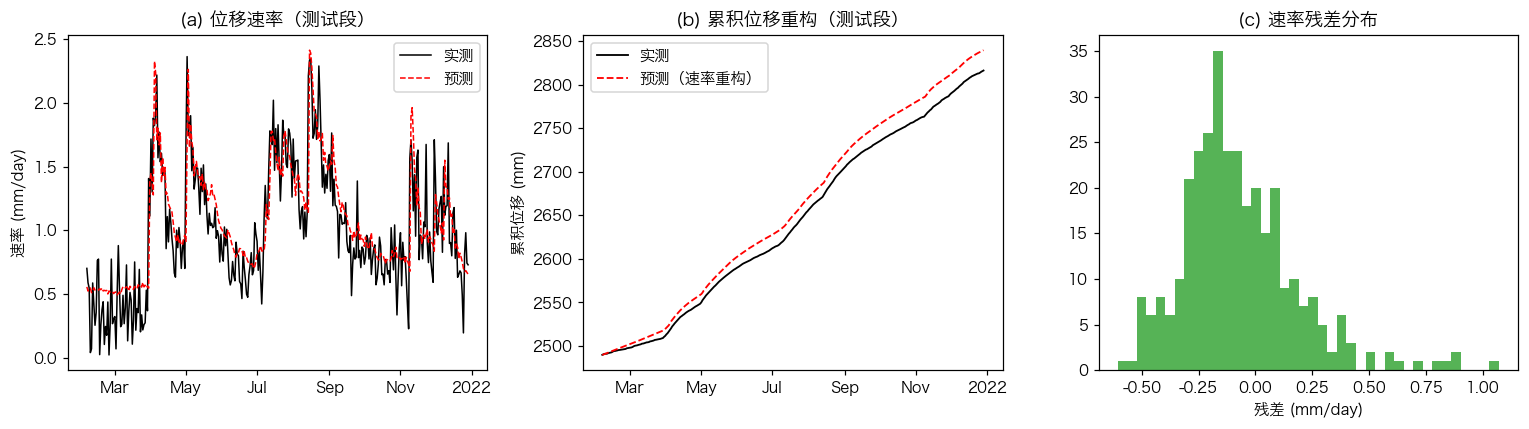

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
ax.plot(dates_end[msk_te], yte.ravel(), "k-", lw=1, label="实测")
ax.plot(dates_end[msk_te], pred_te.ravel(), "r--", lw=1, label="预测")
ax.set_title("(a) 位移速率（测试段）"); ax.set_ylabel("速率 (mm/day)")
ax.legend(); fix_date_axis(ax)

ax = axes[1]
ax.plot(dates_end[msk_te], cum_true_te, "k-", lw=1.2, label="实测")
ax.plot(dates_end[msk_te], rate_to_cum(pred_te, msk_te), "r--", lw=1.2, label="预测（速率重构）")
ax.set_title("(b) 累积位移重构（测试段）"); ax.set_ylabel("累积位移 (mm)")
ax.legend(); fix_date_axis(ax)

ax = axes[2]
ax.hist((yte - pred_te).ravel(), bins=40, color="tab:green", alpha=.8)
ax.set_title("(c) 速率残差分布"); ax.set_xlabel("残差 (mm/day)")

plt.tight_layout(); plt.show()

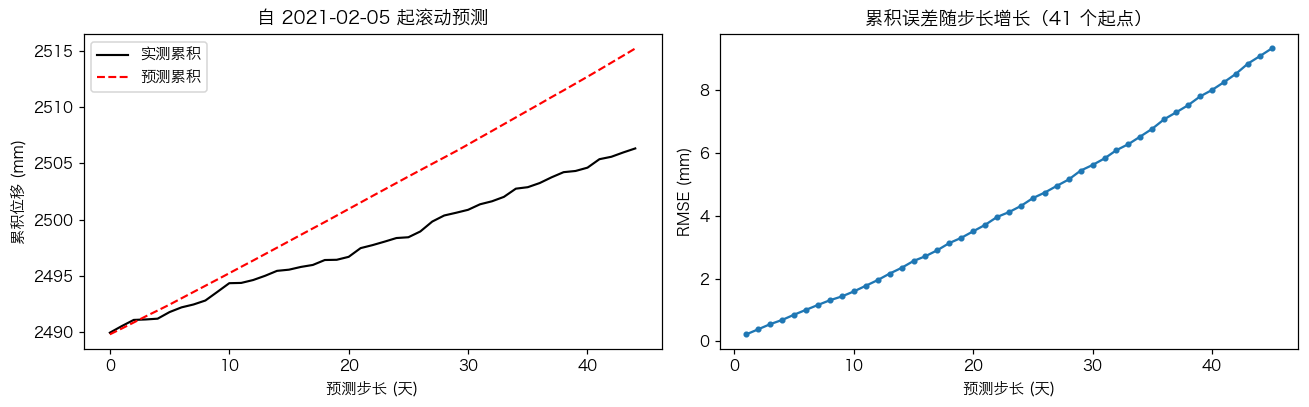

递归预测 RMSE：步长1 = 0.23 mm，步长30 = 5.62 mm


In [19]:
@torch.no_grad()
def recursive_forecast(model, prep_, origin, n_steps):
    """滚动多步预测：预测速率回填输入通道（自回归递归）。
    假设未来驱动由预报/情景给出（此处用合成真值代替）。"""
    model.eval()
    Xf = prep_["Xfull"]
    rate_idx = prep_["cols"].index(TARGET_COL)
    win = Xf[origin - SEQ_LEN:origin].copy()
    preds = []
    for k in range(n_steps):
        p = model(torch.from_numpy(win[None]).to(DEVICE))[0, 0].item()
        preds.append(p)
        new_row = Xf[origin + k].copy()
        new_row[rate_idx] = p
        win = np.vstack([win[1:], new_row[None]])
    rate = prep_["y_scaler"].inverse_transform(np.array(preds)[:, None]).ravel()
    disp0 = prep_["disp"][origin - 1]
    return rate, disp0 + np.cumsum(rate)


N_STEPS = 45
origin0 = prep["i_test"]
_, fc_cum = recursive_forecast(baseline_model, prep, origin0, N_STEPS)
truth0 = prep["disp"][origin0:origin0 + N_STEPS]

n_origins = 0
sq_err = np.zeros(N_STEPS)
for o in range(prep["i_test"], prep["n"] - N_STEPS, 7):
    _, cum_o = recursive_forecast(baseline_model, prep, o, N_STEPS)
    sq_err += (cum_o - prep["disp"][o:o + N_STEPS]) ** 2
    n_origins += 1
rmse_curve = np.sqrt(sq_err / n_origins)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(truth0, "k-", lw=1.4, label="实测累积")
axes[0].plot(fc_cum, "r--", lw=1.4, label="预测累积")
axes[0].set_xlabel("预测步长 (天)"); axes[0].set_ylabel("累积位移 (mm)")
axes[0].set_title(f"自 {pd.Timestamp(prep['dates'][origin0]).date()} 起滚动预测")
axes[0].legend()
axes[1].plot(range(1, N_STEPS + 1), rmse_curve, "o-", ms=3)
axes[1].set_xlabel("预测步长 (天)"); axes[1].set_ylabel("RMSE (mm)")
axes[1].set_title(f"累积误差随步长增长（{n_origins} 个起点）")
plt.tight_layout(); plt.show()
print(f"递归预测 RMSE：步长1 = {rmse_curve[0]:.2f} mm，步长30 = {rmse_curve[29]:.2f} mm")

## 8. 调参

**本架构特有的超参数**：
- `d_model / nhead / layers`：容量三件套（小样本宁小勿大，`nhead` 必须整除 `d_model`）；
- `kernel`：**局部模式宽度**——太小看不见周期/暴雨形态，太大在小样本下欠约束；
- `SEQ_LEN`：**上下文长度**——注意力理论上可以看任意远，但有效上下文受训练分布限制；单独做敏感性实验（§8.3）。

其余（lr / dropout / batch）与 ① §8.1 清单一致。随机搜索：

In [20]:
def fit_eval(name, cfg, prep_, epochs=150, patience=20, split="test", record=True, seed=SEED):
    set_seed(seed)
    model = CNNTransformerRegressor(len(FEATURE_COLS),
                                    d_model=cfg["d_model"], nhead=cfg["nhead"],
                                    n_layers=cfg["layers"], kernel=cfg["kernel"],
                                    dropout=cfg["dropout"], horizon=HORIZON,
                                    use_cnn=cfg.get("use_cnn", True),
                                    use_attn=cfg.get("use_attn", True)).to(DEVICE)
    train_model(model,
                make_loader(prep_["X"][prep_["m_tr"]], prep_["y"][prep_["m_tr"]],
                            cfg.get("batch", BATCH_SIZE), shuffle=True),
                make_loader(prep_["X"][prep_["m_va"]], prep_["y"][prep_["m_va"]], 256),
                lr=cfg["lr"], epochs=epochs, patience=patience, verbose=False)
    msk = prep_[f"m_{SPLIT_KEY[split]}"]
    pred = predict(model, prep_["X"][msk], prep_)
    ytrue = true_real(prep_, split)
    row = regression_metrics(ytrue, pred, name)
    if record:
        RESULTS.append(row)
        PRED_STORE[name] = (ytrue.copy(), pred.copy())
    return model, pred, row

DEFAULT_CFG = dict(d_model=64, nhead=4, layers=2, kernel=5, dropout=0.1, lr=1e-3, batch=BATCH_SIZE)

In [21]:
space_rng = np.random.default_rng(1)
SPACE = dict(d_model=[32, 64], nhead=[2, 4], layers=[1, 2], kernel=[3, 5],
             dropout=[0.0, 0.1], lr=[3e-4, 1e-3, 3e-3], batch=[32, 64])
N_TRIAL, EPOCHS_SEARCH = 10, 60

t0 = time.time()
rows = []
for k in range(N_TRIAL):
    cfg = {p: space_rng.choice(v).item() for p, v in SPACE.items()}
    _, _, r = fit_eval(f"trial{k}", cfg, prep, epochs=EPOCHS_SEARCH, split="val", record=False)
    rows.append({**cfg, "val_RMSE": r["RMSE"]})
    print(f"trial {k:2d} | {cfg} | val RMSE = {r['RMSE']:.4f} mm/day  (累计 {time.time()-t0:.0f}s)")

search_df = pd.DataFrame(rows).sort_values("val_RMSE").reset_index(drop=True)
print("\n验证集 Top-5：")
search_df.head()

trial  0 | {'d_model': 32, 'nhead': 4, 'layers': 2, 'kernel': 5, 'dropout': 0.0, 'lr': 0.0003, 'batch': 64} | val RMSE = 0.2911 mm/day  (累计 32s)


trial  1 | {'d_model': 64, 'nhead': 2, 'layers': 1, 'kernel': 5, 'dropout': 0.0, 'lr': 0.0003, 'batch': 64} | val RMSE = 0.2916 mm/day  (累计 60s)


trial  2 | {'d_model': 32, 'nhead': 2, 'layers': 2, 'kernel': 5, 'dropout': 0.0, 'lr': 0.0003, 'batch': 64} | val RMSE = 0.2903 mm/day  (累计 90s)


trial  3 | {'d_model': 64, 'nhead': 4, 'layers': 2, 'kernel': 5, 'dropout': 0.0, 'lr': 0.001, 'batch': 64} | val RMSE = 0.2891 mm/day  (累计 119s)


trial  4 | {'d_model': 32, 'nhead': 2, 'layers': 1, 'kernel': 3, 'dropout': 0.1, 'lr': 0.0003, 'batch': 32} | val RMSE = 0.2791 mm/day  (累计 147s)


...

trial  6 | {'d_model': 32, 'nhead': 2, 'layers': 1, 'kernel': 3, 'dropout': 0.0, 'lr': 0.003, 'batch': 64} | val RMSE = 0.2840 mm/day  (累计 194s)


trial  7 | {'d_model': 64, 'nhead': 2, 'layers': 2, 'kernel': 3, 'dropout': 0.1, 'lr': 0.003, 'batch': 32} | val RMSE = 0.2895 mm/day  (累计 262s)


trial  8 | {'d_model': 64, 'nhead': 2, 'layers': 1, 'kernel': 5, 'dropout': 0.0, 'lr': 0.001, 'batch': 32} | val RMSE = 0.2922 mm/day  (累计 283s)


trial  9 | {'d_model': 32, 'nhead': 2, 'layers': 2, 'kernel': 3, 'dropout': 0.1, 'lr': 0.001, 'batch': 64} | val RMSE = 0.2828 mm/day  (累计 322s)

验证集 Top-5：


,d_model,nhead,layers,kernel,dropout,lr,batch,val_RMSE
0,32,2,1,3,0.1,0.0003,32,0.279093
1,32,2,2,3,0.1,0.0010,64,0.282826
2,32,2,1,3,0.0,0.0030,64,0.283983
3,64,4,2,5,0.0,0.0010,64,0.289095
4,64,2,2,3,0.1,0.0030,32,0.289457


In [22]:
best_cfg = {p: (int(search_df.iloc[0][p]) if p in ("d_model", "nhead", "layers", "kernel", "batch")
                else float(search_df.iloc[0][p])) for p in SPACE}
print("最优配置:", best_cfg)
tuned_model, _, _ = fit_eval("CNN-Transformer(调参后)", best_cfg, prep, epochs=200)
pd.DataFrame(RESULTS)

最优配置: {'d_model': 32, 'nhead': 2, 'layers': 1, 'kernel': 3, 'dropout': 0.1, 'lr': 0.0003, 'batch': 32}


,模型,RMSE,MAE,MAPE_pct,R2,NSE,最大误差
0,CNN-Transformer(基线),0.264377,0.208311,37.575661,0.707886,0.707886,1.072065
1,CNN-Transformer(调参后),0.263188,0.199583,37.039486,0.710506,0.710506,1.099944


### 8.3 SEQ_LEN 敏感性：长上下文是 Transformer 的主场

LSTM 加长回看窗口，梯度要**多走很多步**（① 的结构瓶颈）；Transformer 任意两步**直连**，
加大 `SEQ_LEN` 只增大注意力矩阵、不拉长信息路径——"长依赖"卖点最直接的实验验证：

SEQ_LEN= 30 | val RMSE = 0.2828 | test RMSE = 0.2624 mm/day


SEQ_LEN= 60 | val RMSE = 0.2791 | test RMSE = 0.2632 mm/day


SEQ_LEN= 90 | val RMSE = 0.2824 | test RMSE = 0.2631 mm/day


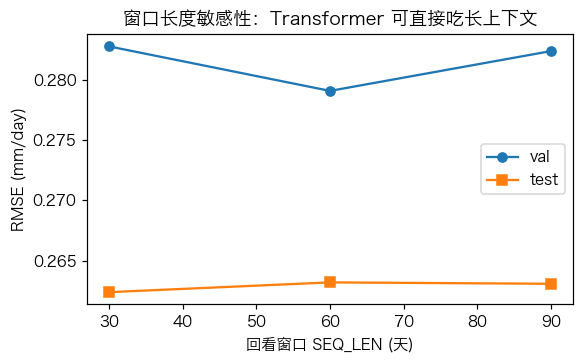

In [23]:
seq_candidates = [30, 60, 90]
rows_seq = []
for L in seq_candidates:
    p_L = build_arrays(df, FEATURE_COLS, TARGET_COL, seq_len=L)
    mdl, _, _ = fit_eval(f"seq{L}", best_cfg, p_L, epochs=120, record=False)
    p_va = predict(mdl, p_L["X"][p_L["m_va"]], p_L)
    p_te = predict(mdl, p_L["X"][p_L["m_te"]], p_L)
    rows_seq.append(dict(SEQ_LEN=L,
                         val_RMSE=math.sqrt(mean_squared_error(true_real(p_L, "val"), p_va)),
                         test_RMSE=math.sqrt(mean_squared_error(true_real(p_L, "test"), p_te))))
    print(f"SEQ_LEN={L:3d} | val RMSE = {rows_seq[-1]['val_RMSE']:.4f} | test RMSE = {rows_seq[-1]['test_RMSE']:.4f} mm/day")

plt.figure(figsize=(5.5, 3.4))
plt.plot(seq_candidates, [r["val_RMSE"] for r in rows_seq], "o-", label="val")
plt.plot(seq_candidates, [r["test_RMSE"] for r in rows_seq], "s-", label="test")
plt.xlabel("回看窗口 SEQ_LEN (天)"); plt.ylabel("RMSE (mm/day)")
plt.title("窗口长度敏感性：Transformer 可直接吃长上下文")
plt.legend(); plt.tight_layout(); plt.show()

**敏感性解读**（如实报告）：窗口加长后训练样本变少（每个窗口要 `SEQ_LEN` 天历史），
若 val RMSE 不降反升，通常说明 60 天内已覆盖有效信息、更长程无规律可学；
若长窗口更好，则直接佐证序列存在 $\gtrsim$ 月尺度的依赖（如跨雨季的水文记忆）。
两种结果都是论文里"上下文长度选择"小节的合格素材。

## 9. 改进方向

| 路线 | 手段 | 本 Notebook |
|---|---|---|
| 消融实验 | 完整 CNN-Transformer / Transformer-only(无CNN) / CNN-only(无注意力) | §9.1 |
| 可解释性 | 逐层注意力热图 + "注意力-滞后"曲线对照渗流滞后核 | §9.2 |
| **物理融合** | 降雨响应核先验（非负 + 指数滞后衰减）→ 卷积核软约束 | §9.3 |
| 不确定性 | MC Dropout 预测区间 | §9.4 |

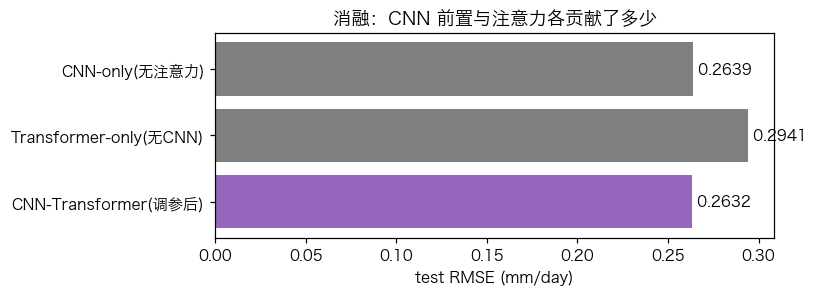

,模型,RMSE,MAE,MAPE_pct,R2,NSE,最大误差
0,CNN-Transformer(基线),0.264377,0.208311,37.575661,0.707886,0.707886,1.072065
1,CNN-Transformer(调参后),0.263188,0.199583,37.039486,0.710506,0.710506,1.099944
2,消融:Transformer-only(无CNN),0.294088,0.231596,43.138168,0.638539,0.638539,1.084730
3,消融:CNN-only(无注意力),0.263910,0.207877,36.586155,0.708916,0.708916,1.083563


In [24]:
# ---------- 9.1 消融：CNN 前置与注意力各贡献了多少？ ----------
no_cnn_model, _, _ = fit_eval("消融:Transformer-only(无CNN)", {**best_cfg, "use_cnn": False}, prep, epochs=200)
no_attn_model, _, _ = fit_eval("消融:CNN-only(无注意力)", {**best_cfg, "use_attn": False}, prep, epochs=200)

abl = ["CNN-Transformer(调参后)", "消融:Transformer-only(无CNN)", "消融:CNN-only(无注意力)"]
vals = [next(r for r in RESULTS if r["模型"] == n)["RMSE"] for n in abl]
plt.figure(figsize=(7.5, 2.8))
plt.barh(range(len(abl)), vals, color=["tab:purple", "tab:gray", "tab:gray"])
plt.yticks(range(len(abl)), [n.replace("消融:", "") for n in abl])
plt.xlabel("test RMSE (mm/day)")
plt.title("消融：CNN 前置与注意力各贡献了多少")
for i, v in enumerate(vals):
    plt.text(v, i, f" {v:.4f}", va="center")
plt.tight_layout(); plt.show()
pd.DataFrame(RESULTS)

**消融解读**（如实报告，三种典型结局都值得写进论文）：
- **CNN-only ≈ 完整模型** → 本数据**局部模式主导**（日尺度 + 一阶指数雨响应），前置 CNN 的归纳偏置即可覆盖大部分规律——参数更少、更稳，"够用的架构就是好架构"；
- **Transformer-only ≈ 完整模型** → 注意力可以部分学出局部模式（卷积能表达的它也能表达），但通常需要更多数据/参数，且收敛更慢——CNN 前置的收益体现为**样本效率与稳定性**；
- **完整模型最优** → 局部与全局分工互补：CNN 把局部形态先压进特征，注意力在更"干净"的特征上找长依赖。
另外两点结构性差异不体现在单步 RMSE 上：**并行训练速度**（Transformer 全窗并行 vs RNN 串行）与**长窗口可扩展性**（§8.3）。

### 9.2 注意力可视化：模型在"回望"哪些历史？

自注意力权重 = "预测当前时刻时，各历史时刻的重要度"。两层证据链：
1. **热图**：query（行）对 key（列）的注意力分布——看模型是否按"时间结构"组织注意力；
2. **"注意力-滞后"曲线**：最后时刻的 query 对各滞后天数的注意力，与降雨渗流滞后核
   $w(k) \propto e^{-k/\tau}$（$\tau=12$ 天，数据生成机制）叠在一起对照——若峰值滞后与物理滞后一致，
   说明注意力确实捕获了"事件 → 延迟响应"的长依赖。

> ⚠️ 注意力权重是"看哪里"的**证据**，不是严格因果归因；多层多头可能分散，解读需谨慎。

注意力权重最大的 3 个滞后（天）: [30, 31, 29] | 权重: [0.02500000037252903, 0.024000000208616257, 0.023000000044703484]


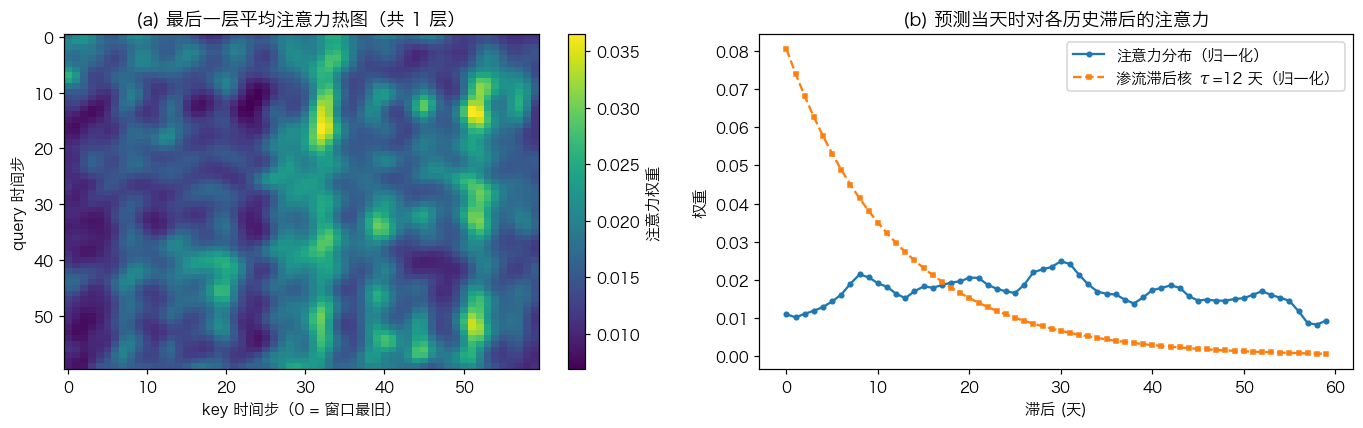

In [25]:
@torch.no_grad()
def get_attention(model, X, n_windows=300):
    """前向并取出各层注意力权重（头平均）。"""
    model.eval()
    _, attns = model(torch.from_numpy(X[-n_windows:]).to(DEVICE), return_attn=True)
    return [a.cpu().numpy() for a in attns]

attn_layers = get_attention(tuned_model, prep["X"][msk_te])
A_last = attn_layers[-1].mean(0)                       # 最后一层、窗口平均 (T, T)
T_win = A_last.shape[0]
attn_by_lag = A_last[-1]                               # 最后时刻的 query → 各 key 位置
lags = np.arange(T_win - 1, -1, -1)                    # key 0 = T−1 天前 … key T−1 = 当天
order = np.argsort(attn_by_lag)[::-1]
print("注意力权重最大的 3 个滞后（天）:", lags[order[:3]].tolist(),
      "| 权重:", attn_by_lag[order[:3]].round(3).tolist())

k_exp = np.exp(-lags / 12.0); k_exp /= k_exp.sum()     # 渗流滞后核（归一化）
attn_norm = attn_by_lag / attn_by_lag.sum()
srt = np.argsort(lags)                                 # 画图按滞后升序

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4))
im = axes[0].imshow(A_last, cmap="viridis", aspect="auto")
axes[0].set_xlabel("key 时间步（0 = 窗口最旧）"); axes[0].set_ylabel("query 时间步")
axes[0].set_title(f"(a) 最后一层平均注意力热图（共 {len(attn_layers)} 层）")
plt.colorbar(im, ax=axes[0], label="注意力权重")

axes[1].plot(lags[srt], attn_norm[srt], "o-", ms=3, label="注意力分布（归一化）")
axes[1].plot(lags[srt], k_exp[srt], "s--", ms=3, label="渗流滞后核 τ=12 天（归一化）")
axes[1].set_xlabel("滞后 (天)"); axes[1].set_ylabel("权重")
axes[1].set_title("(b) 预测当天时对各历史滞后的注意力")
axes[1].legend()
plt.tight_layout(); plt.show()

### 9.3 物理融合：降雨响应核先验（卷积核软约束）

物理：降雨入渗经非饱和带补给坡体，位移速率对降雨的响应应**非负、滞后、衰减**
（工程上常用一阶指数核 $w(k) \propto e^{-k/\tau}$，本数据 $\tau=12$ 天）。而 CNN 第一层作用在降雨通道上的卷积核
$k_{rain} \in \mathbb{R}^K$ 恰好就是"过去 $K$ 天降雨的响应系数"——把这个物理形态写成软约束：

$$\mathcal{L} = \underbrace{\text{MSE}(\hat y, y)}_{\text{数据}} + \lambda\Big[\underbrace{1 - \cos\big(k_{rain},\, k_{exp}\big)}_{\text{形状：滞后衰减}} + \underbrace{\text{mean}\big(\text{ReLU}(-k_{rain})^2\big)}_{\text{非负}}\Big]$$

- 与 ② 的图平滑正则（② §9.3）同一模板：**把"物理上不该发生的事"变成损失项**；
- **核宽要够长**：卷积核只能表达 $K$ 天内的响应——§8 按单步精度选出的 $K$ 往往偏短，装不下 $\tau\approx12$ 天的物理滞后窗，即"调参最优 ≠ 物理可解释"。本节专门把核加宽到 $K=15\,(\approx 2\tau)$ 再谈形状约束；
- λ 在验证集上选择——λ 扫描曲线就是"物理-数据"权衡的显式表达；先验与数据不符时 val RMSE 会明显恶化，λ 自然选小；
- 进阶：把 τ **参数化**并反演（τ 是渗流特征时间，本身就有物理意义），衔接算法⑥ PINN 的参数反演思路。

In [26]:
PRIOR_KERNEL = 15                                     # 物理滞后窗：核宽 ≈ 2τ（比 §8 精度选出的核更长，才能表达衰减形状）
cfg_prior = {**best_cfg, "kernel": PRIOR_KERNEL}


def rain_kernel_penalty(model, kernel_size, tau=12.0, rain_idx=RAIN_IDX):
    """第一层卷积、降雨通道的核：与指数衰减核的形状偏离 + 非负惩罚。"""
    w = model.cnn.net[0].conv.weight[:, rain_idx, :]       # (C_out, K)
    j = torch.arange(kernel_size, device=w.device, dtype=w.dtype)
    k_exp = torch.exp(-j / tau)
    k_exp = k_exp / k_exp.norm()
    wn = w / (w.norm(dim=1, keepdim=True) + 1e-8)          # 尺度自由 → 只约束形状（余弦相似）
    shape = (1 - wn @ k_exp).mean()
    neg = nn.functional.relu(-w).pow(2).mean()
    return shape + neg


def train_prior(cfg, lam, epochs=100, patience=15):
    set_seed(SEED)
    model = CNNTransformerRegressor(len(FEATURE_COLS), d_model=cfg["d_model"], nhead=cfg["nhead"],
                                    n_layers=cfg["layers"], kernel=cfg["kernel"],
                                    dropout=cfg["dropout"], horizon=HORIZON).to(DEVICE)
    tl = make_loader(prep["X"][prep["m_tr"]], prep["y"][prep["m_tr"]], cfg["batch"], shuffle=True)
    vl = make_loader(prep["X"][prep["m_va"]], prep["y"][prep["m_va"]], 256)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg["lr"], weight_decay=1e-4)
    stop = EarlyStopping(patience=patience)
    for ep in range(1, epochs + 1):
        model.train()
        for xb, yb in tl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            loss = nn.functional.mse_loss(model(xb), yb) + lam * rain_kernel_penalty(model, cfg["kernel"])
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
        va = run_epoch(model, vl)
        if stop.step(va, model):
            break
    model.load_state_dict(stop.best_state)
    return model

lam_list = [0.0, 0.3, 1.0, 3.0, 10.0]
val_rmse_l, test_rmse_l, prior_models = [], [], {}
for lam in lam_list:
    prior_models[lam] = train_prior(cfg_prior, lam)
    p_va = predict(prior_models[lam], prep["X"][prep["m_va"]], prep)
    p_te = predict(prior_models[lam], prep["X"][prep["m_te"]], prep)
    val_rmse_l.append(math.sqrt(mean_squared_error(true_real(prep, "val"), p_va)))
    test_rmse_l.append(math.sqrt(mean_squared_error(true_real(prep, "test"), p_te)))
    print(f"λ = {lam:5.1f} | val RMSE = {val_rmse_l[-1]:.4f} | test RMSE = {test_rmse_l[-1]:.4f} mm/day")

lam_best = lam_list[int(np.argmin(val_rmse_l))]
register(f"CNN-Transformer+核正则(K={PRIOR_KERNEL},λ={lam_best})", true_real(prep, "test"),
         predict(prior_models[lam_best], prep["X"][msk_te], prep))
print(f"\n验证集最优 λ* = {lam_best}（K = {PRIOR_KERNEL}）")

λ =   0.0 | val RMSE = 0.3033 | test RMSE = 0.2902 mm/day


λ =   0.3 | val RMSE = 0.3084 | test RMSE = 0.3044 mm/day


λ =   1.0 | val RMSE = 0.3073 | test RMSE = 0.3119 mm/day


λ =   3.0 | val RMSE = 0.3103 | test RMSE = 0.3187 mm/day


λ =  10.0 | val RMSE = 0.3154 | test RMSE = 0.3237 mm/day

验证集最优 λ* = 0.0（K = 15）


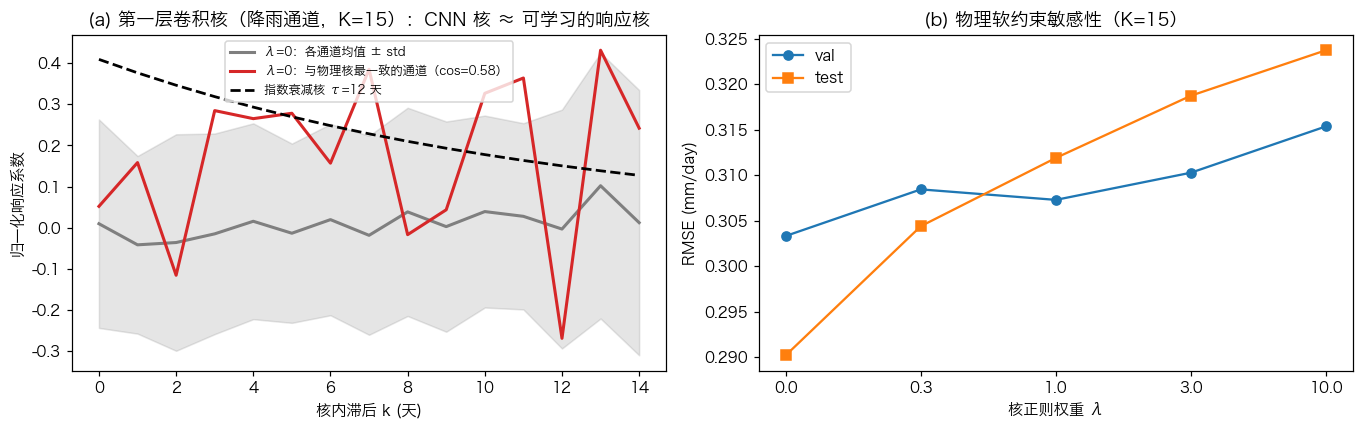

In [27]:
j = np.arange(PRIOR_KERNEL)
k_exp = np.exp(-j / 12.0); k_exp /= np.linalg.norm(k_exp)

def norm_rows(k):
    return k / (np.linalg.norm(k, axis=1, keepdims=True) + 1e-8)

kb = norm_rows(prior_models[0.0].cnn.net[0].conv.weight[:, RAIN_IDX, :].detach().cpu().numpy())
ka = norm_rows(prior_models[lam_best].cnn.net[0].conv.weight[:, RAIN_IDX, :].detach().cpu().numpy())

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4))
ax = axes[0]
mu_b, sd_b = kb.mean(0), kb.std(0)
ax.fill_between(j, mu_b - sd_b, mu_b + sd_b, color="tab:gray", alpha=.2)
ax.plot(j, mu_b, color="tab:gray", lw=2, label="λ=0：各通道均值 ± std")
best_ch = int(np.argmax(kb @ k_exp))
ax.plot(j, kb[best_ch], color="tab:red", lw=2,
        label=f"λ=0：与物理核最一致的通道（cos={float(kb[best_ch] @ k_exp):.2f}）")
if lam_best != 0.0:
    ax.plot(j, ka.mean(0), color="tab:red", lw=2, ls=":", label=f"λ={lam_best}：均值")
ax.plot(j, k_exp, "k--", lw=1.8, label="指数衰减核 τ=12 天")
ax.set_xlabel("核内滞后 k (天)"); ax.set_ylabel("归一化响应系数")
ax.set_title(f"(a) 第一层卷积核（降雨通道，K={PRIOR_KERNEL}）：CNN 核 ≈ 可学习的响应核")
ax.legend(fontsize=8)

ax = axes[1]
xi = range(len(lam_list))
ax.plot(xi, val_rmse_l, "o-", label="val")
ax.plot(xi, test_rmse_l, "s-", label="test")
ax.set_xticks(xi, [str(l) for l in lam_list])
ax.set_xlabel("核正则权重 λ"); ax.set_ylabel("RMSE (mm/day)")
ax.set_title(f"(b) 物理软约束敏感性（K={PRIOR_KERNEL}）")
ax.legend()
plt.tight_layout(); plt.show()

**核正则解读**（如实报告）：
- 看 (a)：无正则（λ=0）时学到的核是否已呈现"非负 + 滞后衰减"形态——若是，说明数据里确实存在该规律，物理先验是"顺水推舟"；**与物理核最一致的那个通道**就是"模型学到了水文规律"的直接证据，可写进论文；
- 若 λ* > 0 且 val RMSE 持平/略降 → 物理约束以近零精度代价换来形状可解释性与外推稳健性，风险评价场景下值得；
- 若 val RMSE 随 λ 明显恶化 → 先验与数据冲突（真实响应非指数形），应换核形状或减小 λ——这正是"数据-物理融合"需要显式权衡的含义。

### 9.4 不确定性量化（MC Dropout）

预测时保持 Dropout 激活采样 N 次 → 预测区间，风险评估可直接用于"超越概率"叙事（与 ① §9.4、② §9.4 同一模板）：

PICP(95%) = 0.512（理想 ≈ 0.95；过低说明区间过自信，讨论见 ① §9.4）


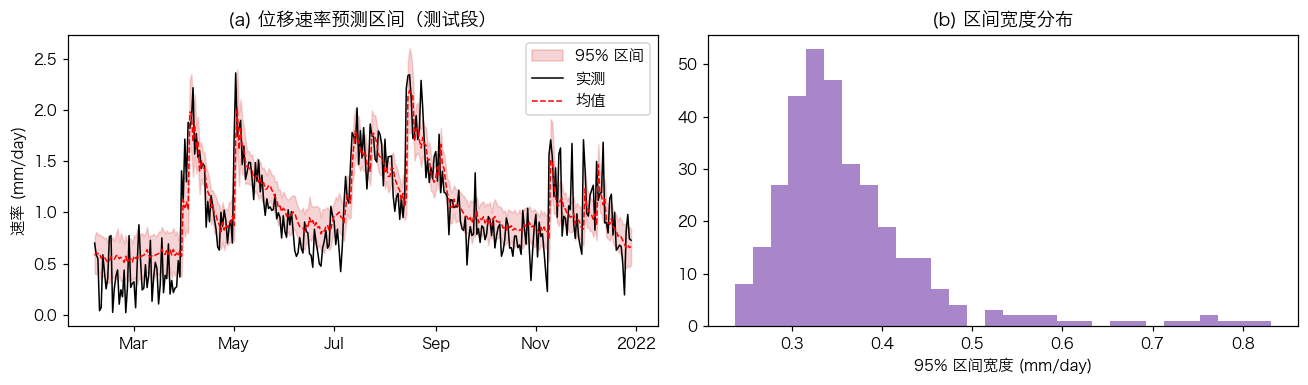

In [28]:
@torch.no_grad()
def mc_dropout_predict(model, X, n_samples=50):
    model.train()
    outs = [model(torch.from_numpy(X).to(DEVICE)).cpu().numpy() for _ in range(n_samples)]
    model.eval()
    return np.mean(outs, 0), np.std(outs, 0)

mean_s, std_s = mc_dropout_predict(tuned_model, prep["X"][msk_te])
mu = prep["y_scaler"].inverse_transform(mean_s).ravel()
sd = std_s.ravel() * prep["y_scaler"].scale_[0]
lo, hi = mu - 1.96 * sd, mu + 1.96 * sd
picp = np.mean((yte.ravel() >= lo) & (yte.ravel() <= hi))
print(f"PICP(95%) = {picp:.3f}（理想 ≈ 0.95；过低说明区间过自信，讨论见 ① §9.4）")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].fill_between(dates_end[msk_te], lo, hi, color="tab:red", alpha=.2, label="95% 区间")
axes[0].plot(dates_end[msk_te], yte.ravel(), "k-", lw=1, label="实测")
axes[0].plot(dates_end[msk_te], mu, "r--", lw=1, label="均值")
axes[0].set_title("(a) 位移速率预测区间（测试段）")
axes[0].set_ylabel("速率 (mm/day)"); axes[0].legend(); fix_date_axis(axes[0])
axes[1].hist(1.96 * 2 * sd, bins=30, color="tab:purple", alpha=.8)
axes[1].set_title("(b) 区间宽度分布"); axes[1].set_xlabel("95% 区间宽度 (mm/day)")
plt.tight_layout(); plt.show()

## 10. 结果汇总与接入真实数据

### 10.1 全部实验汇总（test 集，速率空间 mm/day）

In [29]:
summary = pd.DataFrame(RESULTS).drop_duplicates(subset="模型", keep="last").reset_index(drop=True)
summary.to_csv("cnn_transformer_results_summary.csv", index=False)
print("已保存 cnn_transformer_results_summary.csv")
summary.round(4)

已保存 cnn_transformer_results_summary.csv


,模型,RMSE,MAE,MAPE_pct,R2,NSE,最大误差
0,CNN-Transformer(基线),0.2644,0.2083,37.575699,0.7079,0.7079,1.0721
1,CNN-Transformer(调参后),0.2632,0.1996,37.039501,0.7105,0.7105,1.0999
2,消融:Transformer-only(无CNN),0.2941,0.2316,43.138199,0.6385,0.6385,1.0847
3,消融:CNN-only(无注意力),0.2639,0.2079,36.586201,0.7089,0.7089,1.0836
4,"CNN-Transformer+核正则(K=15,λ=0.0)",0.2902,0.2273,39.113602,0.6480,0.6480,1.0312


**累积重构口径**（应用视角，mm）：

In [30]:
cum_rows = []
ends_te_all = prep["ends"][msk_te]
disp_true_te = prep["disp"][ends_te_all]
for name, (yt_r, yp_r) in PRED_STORE.items():
    cum_rows.append(regression_metrics(disp_true_te,
                                       prep["disp"][ends_te_all[0] - 1] + np.cumsum(yp_r.ravel()), name))
cum_summary = pd.DataFrame(cum_rows).round(3)
cum_summary.to_csv("cnn_transformer_results_summary_cumulative.csv", index=False)
cum_summary

,模型,RMSE,MAE,MAPE_pct,R2,NSE,最大误差
0,CNN-Transformer(基线),15.530,14.181,0.528,0.978,0.978,23.893
1,CNN-Transformer(调参后),10.423,9.757,0.365,0.990,0.990,16.170
2,消融:Transformer-only(无CNN),10.955,10.391,0.390,0.989,0.989,16.195
3,消融:CNN-only(无注意力),15.473,13.625,0.505,0.978,0.978,26.226
4,"CNN-Transformer+核正则(K=15,λ=0.0)",14.243,12.883,0.480,0.981,0.981,23.200


### 10.2 接入真实数据 Checklist

1. ✅ 单点**长表** CSV（date, 驱动列, disp_mm）放入本目录；多测点请配合算法②；
2. ✅ 改 §2.2 配置区：`DATA_PATH / FEATURE_COLS / TARGET_COL`；位移类目标先差分出速率列；
3. ✅ `SEQ_LEN` 按物理记忆尺度选（跨雨季水文记忆 → 90~180 天；无长记忆 → 30~60 天），用 §8.3 敏感性实验定；
4. ✅ 样本量小（<1k 窗口）时：保住 CNN 前置（归纳偏置省样本）、减小 `d_model/layers`、加大 dropout；
5. ✅ 先跑基线 → §9.1 消融论证"CNN 前置"的必要性（审稿人必问）→ §9.2 注意力-滞后对照证长依赖 → §9.3 响应核先验（可直接读出渗流滞后）；
6. ✅ 风险评估：§9.4 预测区间 → 超越概率 → 风险矩阵（衔接算法⑤）。

### 10.3 进阶路线（与 ②⑤⑥⑧ 衔接）

| 方向 | 做法 | 关键词 |
|---|---|---|
| 架构 | Patch 化输入（分段 embedding，PatchTST）、频域混合（FEDformer）、稀疏注意力（Informer）降 O(T²) | efficient TS-Transformer |
| 时空扩展 | 与 ② 结合：Transformer 管时间 + GCN 管空间（ST-Transformer），替换 GRU | spatio-temporal |
| 物理融合 | 响应核 τ 参数化并反演；把注意力约束在物理滞后窗内（masked attention） | physics-guided attention |
| 学习率 | warmup + 余弦退火（Transformer 惯例），大批量训练时更稳 | LR schedule |
| 基础模型 | Chronos/TimesFM zero-shot 对比（算法⑧） | time series foundation model |

**常见坑速查**：位置编码忘加（注意力对顺序无感）❌｜`nhead` 不整除 `d_model` ❌｜小样本直接上大 Transformer（过拟合，CNN 前置兜底）❌｜post-LN 无 warmup 训崩（用 pre-LN）❌｜全量数据 fit scaler ❌｜直接预测累积位移 ❌｜随机划分样本 ❌｜把注意力权重当因果证据 ❌